$ \textbf{Aluna:}$ Alessandra da Silva Dias Malizia   
$ \textbf{Professor:}$ Cristiano Fernandes   
$ \textbf{Data:}$ Abril de 2026   

$ \textbf{Estudo Orientado - 2026.1}$

In [1]:
import numpy as np
import math
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import statsmodels.api as sm
from matplotlib.ticker import PercentFormatter
import pandas as pd
from scipy.stats import norm, t, genpareto, genextreme, chi2, gamma, uniform
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 
from arch import arch_model

In [2]:
rng = np.random.default_rng(seed=4)

In [3]:
path_img = r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\EO - chuvas"

# Dados
Dados baixados da base do Inmet pelo site https://basedosdados.org/dataset/782c5607-9f69-4e12-b0d5-aa0f1a7a94e2?table=28d16282-d100-4ea8-9dde-36c05c8f1ca2 em 04/04/2026

In [4]:
data = pd.read_csv(r"C:\Users\aless\Documents\Mestrado\PUC\Tese\propostas\dados de chuva quinzenal - porto alegre.csv").rename(columns={'quinzena': 'data', 'precipitacao_total': 'precipitacao'})
data['data'] = pd.to_datetime(data['data'])
series = data[['precipitacao','data']].set_index('data')['precipitacao']

data.head()

,id_estacao,estacao,data_fundacao,data,precipitacao
0,A801,Porto Alegre,2000-09-22,2000-10-04,102.0
1,A801,Porto Alegre,2000-09-22,2000-10-19,70.0
2,A801,Porto Alegre,2000-09-22,2000-11-03,26.8
3,A801,Porto Alegre,2000-09-22,2000-11-18,52.8
4,A801,Porto Alegre,2000-09-22,2000-12-03,76.6


In [5]:
series.sort_values().head(10)

data
2025-04-26    0.0
2021-04-17    0.2
2005-06-10    0.2
2013-12-25    0.2
2002-06-26    0.4
2009-05-05    0.4
2008-05-25    0.6
2003-08-20    0.6
2003-05-22    0.8
2020-10-19    1.0
Name: precipitacao, dtype: float64

In [6]:
series = series[series.index < pd.to_datetime('2025-04-26')]
pd.DataFrame(index=['Metadados'], data={
    'Série':'Precipitação quinzenal em Porto Alegre (mm)', 
    'Fonte': 'Inmet',
    'Período da série': '{} a {}'.format(series.index[0].strftime('%d/%m/%Y'), series.index[-1].strftime('%d/%m/%Y')),
    'Observações': '{}'.format(series.shape[0])
}).T

,Metadados
Série,Precipitação quinzenal em Porto Alegre (mm)
Fonte,Inmet
Período da série,04/10/2000 a 11/04/2025
Observações,597


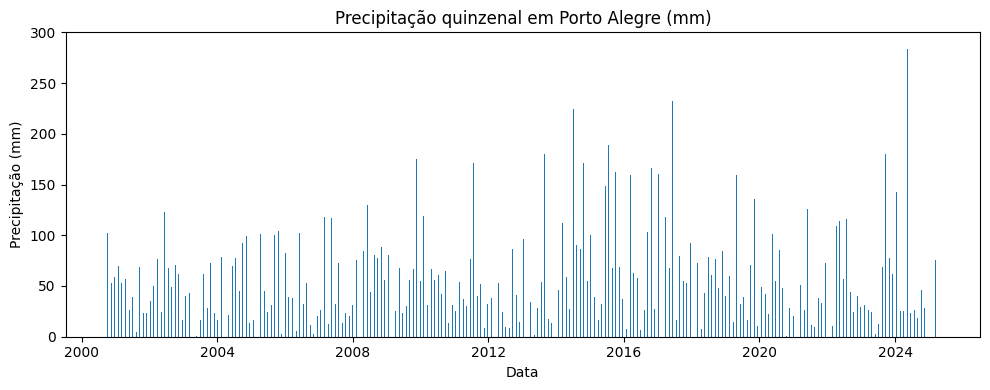

In [7]:
fig, ax = plt.subplots(figsize=(10,4))

ax.bar(series.index, series, width=4)
ax.set_title('Precipitação quinzenal em Porto Alegre (mm)')
ax.set_ylabel('Precipitação (mm)')
ax.set_xlabel('Data')
ax.set_ylim(top=300)
plt.tight_layout()
plt.show()

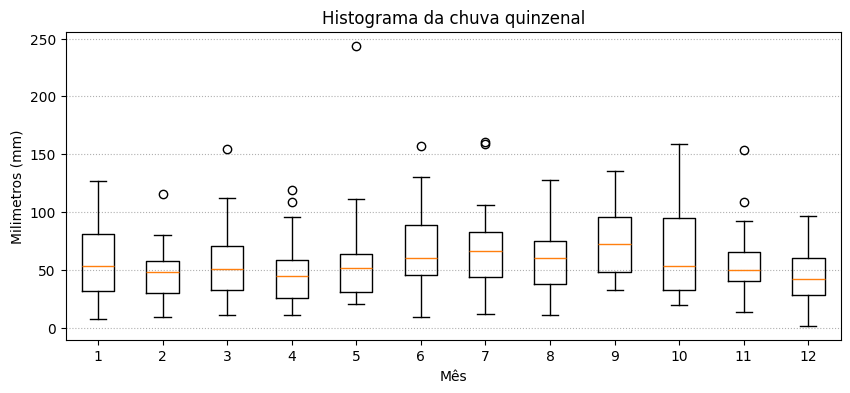

In [8]:
fig, ax = plt.subplots(figsize=(10,4))
plot_data = (series.to_frame()
    # .diff()
    .pivot_table(columns=series.index.month, index=series.index.year, values='precipitacao')
    .dropna()
)
ax.boxplot(plot_data)
ax.set_ylabel('Milimetros (mm)')
ax.set_xlabel('Mês')
ax.grid(axis='y', linestyle=':')
ax.set_title('Histograma da chuva quinzenal')
plt.show()

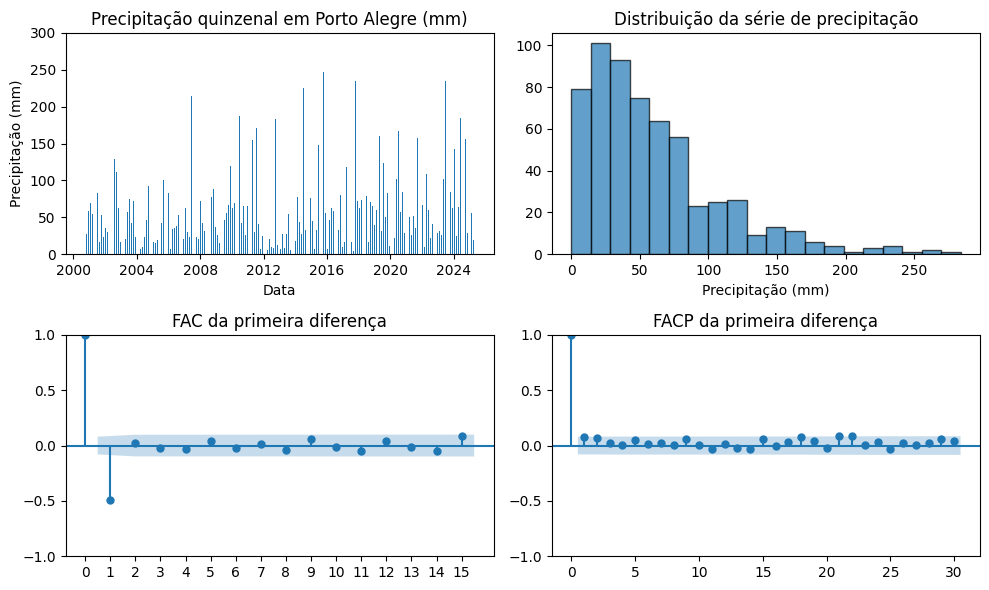

In [21]:
plot_count=0

fig, ax = plt.subplots(2, 2, figsize=(10, 6))

ax[0][0].bar(series.index, series, width=6)
ax[0][0].set_title('Precipitação quinzenal em Porto Alegre (mm)')
ax[0][0].set_ylabel('Precipitação (mm)')
ax[0][0].set_xlabel('Data')
ax[0][0].set_ylim(top=300)

ax[0][1].hist(series, bins=20, density=False, alpha=0.7, edgecolor='black')
# ax[0][1].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax[0][1].set_title('Distribuição da série de precipitação')
ax[0][1].set_xlabel('Precipitação (mm)')

lags=15
plot_acf(series.diff().dropna(),lags=lags, ax=ax[1][0], title=f'FAC da primeira diferença')
ax[1][0].set_xticks(np.arange(lags+1))
ax[1][0].set_xticklabels(np.arange(lags+1))

plot_pacf(series.diff().dropna(),lags=lags, ax=ax[1][1], title=f'FACP da primeira diferença')
ax[1][1].set_xticks(np.arange(lags+1))
ax[1][1].set_xticklabels(np.arange(lags+1))

fig.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

# Modelagem

## Gamma
$$
y_t \sim \text{Gamma}(\alpha, \theta) \\
$$

In [10]:
gamma_params = gamma.fit(series, floc=0)
alpha_hat, loc_hat, theta_hat = gamma_params

x = np.linspace(series.min(), series.max(), 100)
pit = gamma.cdf(series, alpha_hat, loc=loc_hat, scale=theta_hat)

print(f"Parâmetros estimados da Gamma:\nalpha={alpha_hat:.2f}, loc={loc_hat:.2f}, theta={theta_hat:.2f}")

df_quantiles = pd.DataFrame(index=['Gamma','GPD', 'GPD + Gamma','GPD + Pit'],
                           columns = ['95.0%','99.0%','99.9%'])
for alpha in [0.95, 0.99, 0.999]:
    df_quantiles.loc['Gamma', f'{(alpha*100)}%'] = gamma.ppf(alpha, alpha_hat, loc=loc_hat, scale=theta_hat)

Parâmetros estimados da Gamma:
alpha=1.36, loc=0.00, theta=44.33


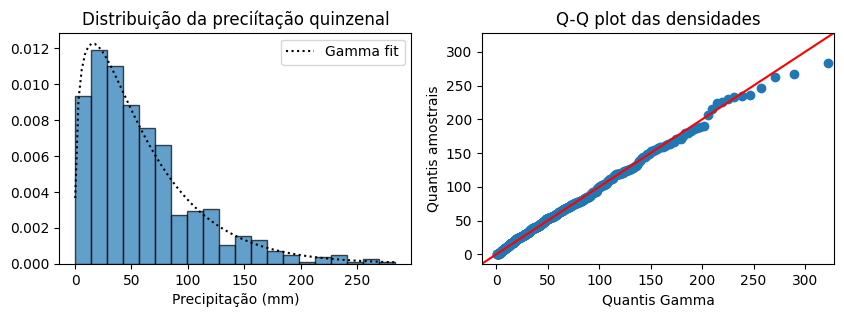

In [11]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].plot(x, gamma.pdf(x, alpha_hat, loc=loc_hat, scale=theta_hat), 'k', linestyle=':', label='Gamma fit')
ax[0].hist(series, bins=20, density=True, alpha=0.7, edgecolor='black')
ax[0].set_title('Distribuição da preciítação quinzenal')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].legend()

ax[1].set_title(f'Q-Q plot das densidades')
sm.qqplot(series, ax=ax[1], line='45', dist=gamma, distargs=(alpha_hat,), loc=loc_hat, scale=theta_hat)
ax[1].set_xlabel('Quantis Gamma')
ax[1].set_ylabel('Quantis amostrais')

plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

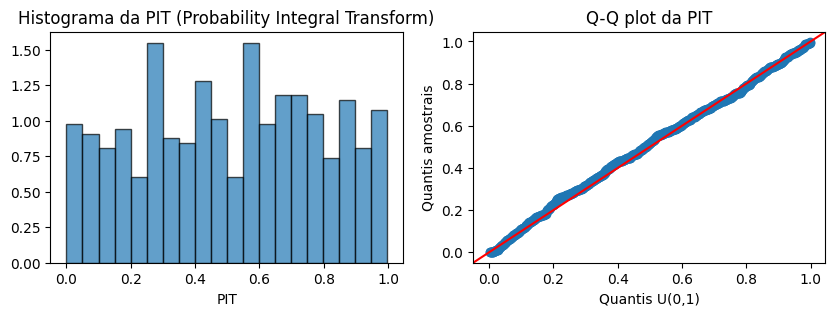

In [12]:
fig, ax = plt.subplots(1,2, figsize=(10, 3))

ax[0].hist(pit, bins=20, density=True, edgecolor='black', alpha=0.7)
ax[0].set_title('Histograma da PIT (Probability Integral Transform)')
ax[0].set_xlabel('PIT')

ax[1].set_title(f'Q-Q plot da PIT')
sm.qqplot(pit, dist=uniform, line='45', ax=ax[1], loc=0, scale=1)
ax[1].set_xlabel('Quantis U(0,1)')
ax[1].set_ylabel('Quantis amostrais')

plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

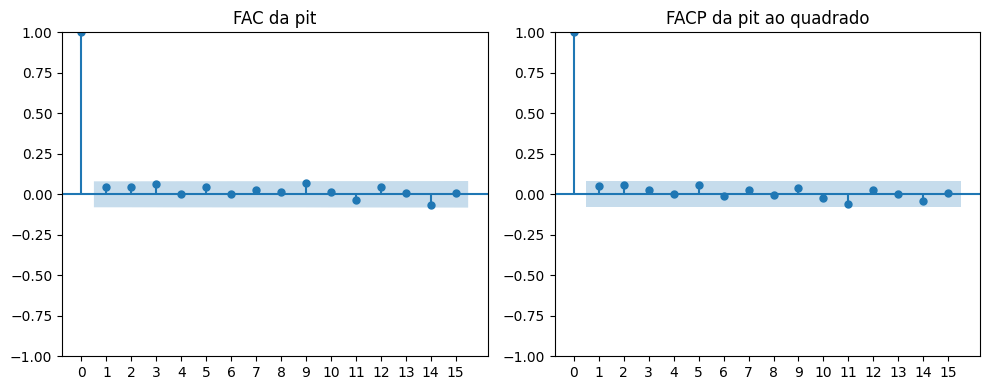

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

lags=15
plot_acf(pit,lags=lags, ax=ax[0], title=f'FAC da pit')
ax[0].set_xticks(np.arange(lags+1))
ax[0].set_xticklabels(np.arange(lags+1))

plot_pacf(pit**(2),lags=lags, ax=ax[1], title=f'FACP da pit ao quadrado')
ax[1].set_xticks(np.arange(lags+1))
ax[1].set_xticklabels(np.arange(lags+1))

fig.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

## GPD

$$
\begin{aligned}
y_t &\sim \text{GPD}(\xi, \beta) \\   
q_{alpha} &= u + \frac{\beta}{\xi} \left( \left( \frac{1 - \alpha}{p_u} \right)^{-\xi} - 1 \right), \quad \text{onde} \quad p_u = P(Y > u)
\end{aligned}
$$

In [13]:
thresholds = np.arange(0.8, 0.95, 0.01)
threshold_values = np.quantile(series, thresholds)
obs_below = [(series > t).sum() for t in threshold_values]
df_thresholds = pd.DataFrame({
    'Threshold (%)': thresholds * 100,
    'Threshold value (mm)': threshold_values,
    'Obs below': obs_below
})
print(df_thresholds)

    Threshold (%)  Threshold value (mm)  Obs below
0            80.0                91.440        120
1            81.0                92.752        114
2            82.0                98.088        108
3            83.0               101.208        102
4            84.0               103.256         96
5            85.0               107.680         90
6            86.0               111.760         84
7            87.0               116.536         78
8            88.0               118.696         72
9            89.0               121.064         66
10           90.0               124.640         60
11           91.0               128.632         54
12           92.0               138.128         48
13           93.0               145.136         42
14           94.0               153.744         36


83% threshold: 101.21mm
Quantidade de observações extremas: 102


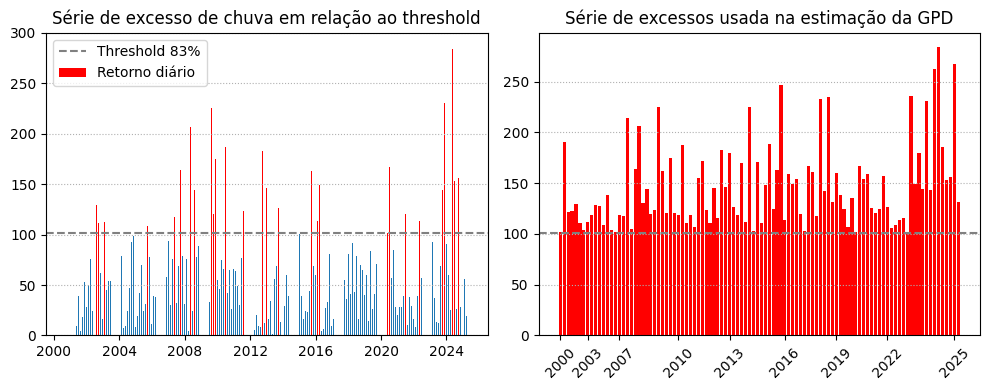

In [14]:
alpha_t = 0.83
threshold = np.quantile(series, alpha_t)
exceedances = series[series > threshold] - threshold

print(f"{alpha_t:.0%} threshold: {threshold:.2f}mm")
print(f'Quantidade de observações extremas: {exceedances.shape[0]}')

fig, ax = plt.subplots(1,2,figsize=(10,4))

bar_colors = ['red' if v > threshold else 'C0' for v in series]
ax[0].bar(series.index, series, width=6, color=bar_colors, label='Retorno diário')
ax[0].axhline(threshold, color='gray', linestyle='--', label='Threshold {:.0%}'.format(alpha_t))
ax[0].set_ylim(top=300)
ax[0].grid(axis='y', linestyle=':')
ax[0].legend()
ax[0].set_title('Série de excesso de chuva em relação ao threshold')

ticks, labels = [], []
years = exceedances.sort_index().index.year
unique_years = sorted(years.unique())
for y in unique_years[::3]:
    idx = np.where(years == y)[0][0]
    ticks.append(idx)
    labels.append(str(y))
        
ax[1].bar(np.arange(len(exceedances)), series[series > threshold].sort_index(), color='red', label='Excessos')
ax[1].set_xticks(ticks)
ax[1].set_xticklabels(labels, rotation=45)
ax[1].axhline(threshold, color='gray', linestyle='--', label=f'Threshold {alpha_t:.0%}')
ax[1].grid(axis='y', linestyle=':')
ax[1].set_title('Série de excessos usada na estimação da GPD')

fig.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()

In [15]:
xi, loc, beta = genpareto.fit(exceedances, floc=0)
y_gpd = genpareto.pdf((x[x > threshold] - threshold), xi, loc=loc, scale=beta)
print('Parâmetros estimados da GPD: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil    
for alpha in [0.95, 0.99, 0.999]:
    # GPD pura com p_u empírico
    p_u = len(exceedances) / len(series)
    q = threshold + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    df_quantiles.loc['GPD', f'{(alpha*100)}%'] = q
    
    # GPD com Gamma
    p_u = 1 - gamma.cdf(threshold, alpha_hat, loc=loc_hat, scale=theta_hat)
    q = threshold + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    df_quantiles.loc['GPD + Gamma', f'{(alpha*100)}%'] = q
    

Parâmetros estimados da GPD: 
xi=-0.14 
loc=0.0000 
scale=52.5393


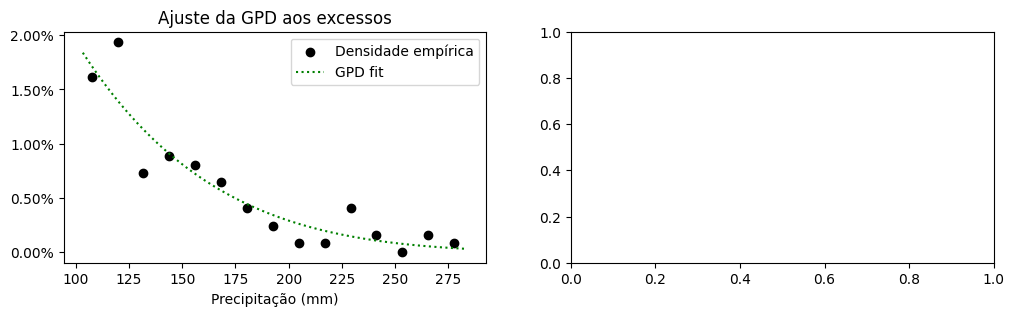

In [16]:
fig, ax = plt.subplots(1,2,figsize=(12,3))

hist, bin_edges = np.histogram(series[series > threshold], bins=15, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
ax[0].scatter(bin_centers, hist, color='black', label='Densidade empírica')
ax[0].plot(x[x > threshold], y_gpd, 'g', linestyle=':', label='GPD fit')
ax[0].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=2))
ax[0].set_title('Ajuste da GPD aos excessos')
ax[0].set_xlabel('Precipitação (mm)')
ax[0].legend()

# hist, bin_edges = np.histogram(monthly_min, bins=15, density=True)
# bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
# ax[1].scatter(bin_centers, hist, color='black', label='Densidade empírica')
# ax[1].plot(x[y_gev > 0], y_gev[y_gev > 0], 'b', linestyle=':', label='GEV fit')
# ax[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
# ax[1].set_title('AAPL | Ajuste GEV aos mínimos mensais')
# ax[1].set_xlabel('Retorno (%)')
# ax[1].legend()

plt.show()

## GPD na Pit

In [17]:
u = 0.85
pit_exceedances = pit[pit > u] - u
print(f'Quantidade de observações extremas: {pit_exceedances.shape[0]}')

xi, loc, beta = genpareto.fit(pit_exceedances, floc=0)
# y_gpd = genpareto.pdf((x[x > threshold] - threshold), xi, loc=loc, scale=beta)
print('\nParâmetros estimados da GPD na pit: \nxi={:.2f} \nloc={:.4f} \nscale={:.4f}'.format(xi, loc, beta))

# cálculo do quantil    
for alpha in [0.95, 0.99, 0.999]:
    # quantil da GPD sobre a pit
    p_u = len(pit_exceedances) / len(pit)
    q_u = u + (beta/xi) * (((1-alpha) / p_u)**(-xi) - 1)
    # quantil da série usando a pit como entrada para a gamma inversa
    q = gamma.ppf(q_u, a=alpha_hat, loc=loc_hat, scale=theta_hat)
    df_quantiles.loc['GPD + Pit', f'{(alpha*100)}%'] = q 

Quantidade de observações extremas: 89

Parâmetros estimados da GPD na pit: 
xi=-1.07 
loc=0.0000 
scale=0.1568


# Resultados

In [18]:
df_quantiles.astype(float).round(2)

,95.0%,99.0%,99.9%
Gamma,162.11,238.54,345.76
GPD,160.40,223.71,292.29
GPD + Gamma,161.10,224.27,292.69
GPD + Pit,162.98,230.49,276.10


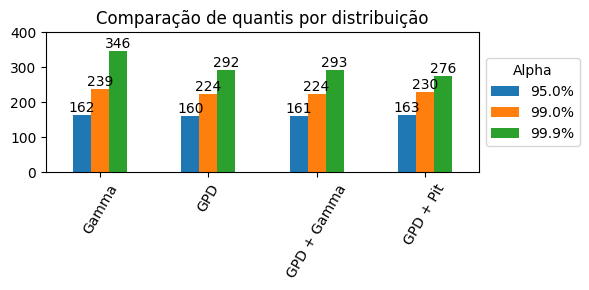

In [19]:
ax = df_quantiles.plot(kind="bar", figsize=(6,3))

ax.set_title("Comparação de quantis por distribuição")
ax.set_ylim(0,400)
# ax.invert_yaxis()
# ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(title="Alpha",
          loc='center left',
          bbox_to_anchor=(1, 0.5))
for label in ax.get_xticklabels():
    label.set_rotation(60)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f",
                 labels=[f"{v:.0f}" for v in container.datavalues])
plt.tight_layout()
plot_count+=1
plt.savefig(path_img + r"\plot{}.png".format(plot_count))
plt.show()